<a href="https://colab.research.google.com/github/burningdust/ESAA/blob/main/YB_assignment/ESAA_YB_study21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 개념 정리

### 7-3. 평균 이동


평균 이동(Mean Shift) : 데이터의 분포도를 이용해 군집 중심점을 찾고 중심을 군집의 중심으로 지속적으로 움직이면서 군집화를 수행하는 방식. 확률밀도함수를 기준으로 하며 이를 찾기 위해 KDE 이용.
- KDE(Kernel Density Estimation): 커널 함수를 통해 확률 밀도 함수를 추정하는 방법. 대표적인 커널 함수로 가우시안 분포 함수 사용. 대역폭 h에 따라 평활화 정도 조정.
- 대역폭이 클수록 적은 수의 군집 중심점을 가짐. 군집 개수를 지정하지 않고 대역폭의 크기에 따라 수행함.
- 유연한 군집화가 가능하며 이상치의 영향력이 크지 않음.
- 알고리즘 수행 시간이 오래 걸리며 band_width 크기에 따른 군집화 영향도가 큼.

MeanShift 클래스로 구현
- bandwidth : 대역폭  
estimate_bandwidth() 함수로 최적의 대역폭 계산

### 7-4. GMM(Gaussian Mixture Model)

GMM : 군집화를 적용하고자 하는 데이터가 여러 개의 가우시안 분포가 섞여 생성된 것이라는 가정하에 군집화를 수행하는 방식. 분포들의 평균과 분산, 데이터가 각 정규분포에 해당될 확률을 모수로 하여 EM 알고리즘 방식으로 추정.
- KMeans는 원형의 범위에서 군집화를 수행하므로 데이터가 원형으로 퍼져있지 않을 경우 군집화 정확성이 떨어짐. 이 경우 GMM이 더 유리.
- 다양한 데이터 세트에 잘 적용될 수 있으나 수행 시간이 오래 걸림.

# 코드 필사

### 7-3. 평균 이동

In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

X, y = make_blobs(n_samples = 200, n_features = 2, centers = 3, cluster_std = 0.7, random_state = 0)

meanshift = MeanShift(bandwidth = 0.8)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2 3 4 5]


In [6]:
meanshift = MeanShift(bandwidth = 1)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


In [7]:
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X)
print('bandwidth 값:', round(bandwidth, 3))

bandwidth 값: 1.816


In [8]:
import pandas as pd

clusterDF = pd.DataFrame(data = X, columns = ['ftr1', 'ftr2'])
clusterDF['target'] = y

# estimate_bandwidth()로 최적의 bandwidth 계산
best_bandwidth = estimate_bandwidth(X)

meanshift = MeanShift(bandwidth = best_bandwidth)
clutser_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


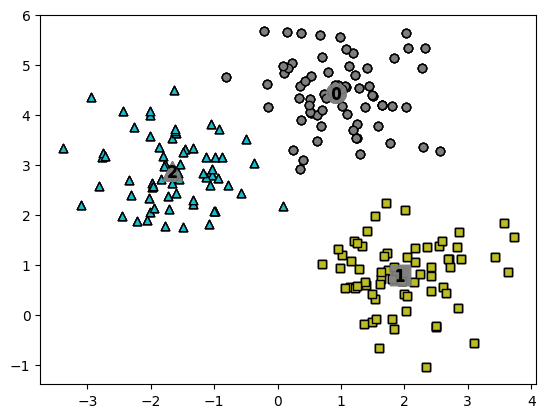

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

clusterDF['meanshift_label'] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = clusterDF[clusterDF['target'] == label]
    center_x_y = centers[label]
    # 군집별로 다른 마커로 산점도 적용
    plt.scatter(x = label_cluster['ftr1'], y = label_cluster['ftr2'], edgecolor = 'k',
                marker = markers[label])

    # 군집별 중심 표현
    plt.scatter(x = center_x_y[0], y = center_x_y[1], s = 200, color = 'gray', alpha = 0.9,
                marker = markers[label])
    plt.scatter(x = center_x_y[0], y = center_x_y[1], s = 70, color = 'k',
                edgecolor = 'k', marker = '$%d$' % label)

plt.show()

In [13]:
print(clusterDF.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       1                  67
1       0                  67
2       2                  66
Name: count, dtype: int64


### 7-4. GMM(Gaussian Mixture Model)

In [14]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# 좀 더 편리한 데이터 Handling을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data = iris.data, columns = feature_names)
irisDF['target'] = iris.target

In [15]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components = 3, random_state = 0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)

# 군집화 결과를 irisDF의 'gmm_cluster' 칼럼명으로 저장
irisDF['gmm_cluster'] = gmm_cluster_labels
irisDF['target'] = iris.target

# target 값에 따라 gmm_cluster 값이 어떻게 매핑됐는지 확인
iris_result = irisDF.groupby(['target'])['gmm_cluster'].value_counts()
print(iris_result)

target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64


In [16]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, random_state = 0).fit(iris.data)
kmeans_cluster_labels = kmeans.predict(iris.data)
irisDF['kmeans_cluster'] = kmeans_cluster_labels
iris_result = irisDF.groupby(['target'])['kmeans_cluster'].value_counts()
print(iris_result)

target  kmeans_cluster
0       1                 50
1       0                 47
        2                  3
2       2                 36
        0                 14
Name: count, dtype: int64


In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
%matplotlib inline

def visualize_cluster_plot(cluster_result=None, dataframe=None, label_name='target', iscenter=True):
  if dataframe is None:
    print("Error: DataFrame is required.")
    return

  unique_labels = np.unique(dataframe[label_name])
  markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']

  for label in unique_labels:
    label_cluster = dataframe[dataframe[label_name] == label]
    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
    marker=markers[label % len(markers)])

    if iscenter and cluster_result is not None and hasattr(cluster_result, 'cluster_centers_'):
      # Assuming cluster_result has a .cluster_centers_ attribute
      center_x_y = cluster_result.cluster_centers_[label]
      plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9,
      marker=markers[label % len(markers)])
      plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k',
      marker='$%d$' % label)

  plt.show()

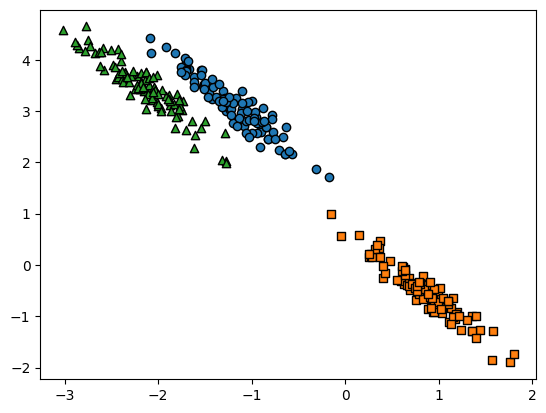

In [19]:
from sklearn.datasets import make_blobs

# make_blobs()로 300개의 데이터 세트, 3개의 군집 세트, cluster_std = 0.5를 만듦.
X, y = make_blobs(n_samples = 300, n_features = 2, centers = 3, cluster_std = 0.5, random_state = 0)

# 길게 늘어난 타원형의 데이터 세트를 생성하기 위해 변환함.
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X, transformation)
# feature 데이터 세트와 make_blobs()의 y 결괏값을 DataFrame으로 저장
clusterDF = pd.DataFrame(data = X_aniso, columns = ['ftr1', 'ftr2'])
clusterDF['target'] = y
# 생성된 데이터 세트를 target 별로 다른 마커로 표시해 시각화함
visualize_cluster_plot(dataframe = clusterDF, iscenter = False)

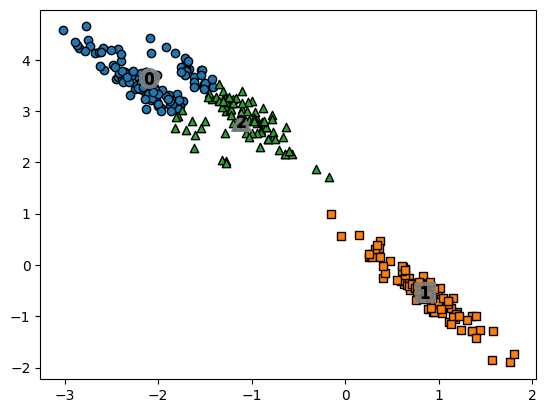

In [23]:
# 3개의 군집 기반 Kmeansㄹ를 X_aniso 데이터 세트에 적용
kmeans = KMeans(3, random_state = 0)
kmeans_label = kmeans.fit_predict(X_aniso)
clusterDF['kmeans_label'] = kmeans_label

visualize_cluster_plot(kmeans, clusterDF, 'kmeans_label', iscenter = True)

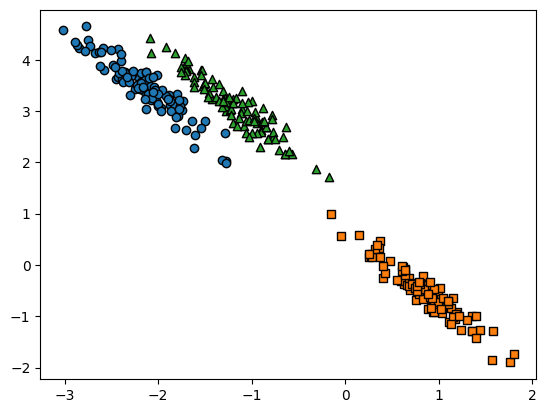

In [24]:
# 3개의 n_components기반 GMM을 X_aniso 데이터 세트에 적용
gmm = GaussianMixture(n_components = 3, random_state = 0)
gmm_label = gmm.fit(X_aniso).predict(X_aniso)
clusterDF['gmm_label'] = gmm_label

# GaussianMixture는 cluster_centers_ 속성이 없으므로 iscenter를 False로 설정.
visualize_cluster_plot(gmm, clusterDF, 'gmm_label', iscenter = False)

In [25]:
print('### KMeans Clustering ###')
print(clusterDF.groupby('target')['kmeans_label'].value_counts())
print('\n### Gaussian Mixture Clustering ###')
print(clusterDF.groupby('target')['gmm_label'].value_counts())

### KMeans Clustering ###
target  kmeans_label
0       2                73
        0                27
1       1               100
2       0                86
        2                14
Name: count, dtype: int64

### Gaussian Mixture Clustering ###
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: count, dtype: int64
